# TAM - Implementación de la base de datos financiera 2010-presente

Este notebook construye la **base de datos principal** del proyecto TAM para la fase de datos.  
La arquitectura predictiva se trabajará después; aquí solo se realiza:

1. Descarga de precios diarios con `yfinance`.
2. Descarga de variables macroeconómicas y de mercado amplio desde FRED.
3. Normalización de columnas.
4. Cálculo de retornos y volatilidad.
5. Alineación temporal diaria.
6. Generación de archivos `raw`, `processed` y `final`.

## Fuentes principales

- **Precios diarios:** `yfinance` / Yahoo Finance.
- **Macroeconomía y mercado amplio:** FRED.
- **Fuentes de control opcionales:** Alpha Vantage y Nasdaq Data Link.

## Activos financieros

- `VOO`: Vanguard S&P 500 ETF.
- `SPY`: SPDR S&P 500 ETF.
- `^GSPC`: S&P 500 Index.
- `GLD`: SPDR Gold Shares.
- `GC=F`: futuros de oro.

## Variables FRED

- `VIXCLS`: CBOE Volatility Index.
- `DGS10`: Treasury yield 10 años.
- `DGS2`: Treasury yield 2 años.
- `FEDFUNDS`: Federal Funds Rate.
- `CPIAUCSL`: Consumer Price Index.
- `UNRATE`: tasa de desempleo.
- `DTWEXBGS`: índice amplio del dólar.

> Nota metodológica: se descarga desde 2010-01-01, pero la base final puede recortarse automáticamente al primer día válido de VOO para mantener homogeneidad.

In [18]:
# ============================================================
# 1. Instalación de dependencias
# ============================================================

!pip install -q yfinance requests pandas numpy

In [19]:
# ============================================================
# 2. Imports y configuración general
# ============================================================

from pathlib import Path
from datetime import datetime
import time
import json
import requests
import numpy as np
import pandas as pd
import yfinance as yf

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# ------------------------------------------------------------
# Configuración temporal
# ------------------------------------------------------------
DOWNLOAD_START_DATE = "2010-01-01"
DOWNLOAD_END_DATE = None  # None = hasta la fecha disponible más reciente

# Si True, la tabla final se recorta al primer día disponible de VOO.
# Esto evita valores faltantes estructurales al inicio.
TRIM_TO_VOO_FIRST_VALID_DATE = True

# ------------------------------------------------------------
# Configuración de proyecto
# ------------------------------------------------------------
# Opción A: trabajo temporal en Colab
#PROJECT_ROOT = Path("/content/tam_financial_database")

# Opción B: usar Google Drive.
# Descomenta estas líneas si quieres guardar directamente en Drive.
from google.colab import drive
drive.mount("/content/drive")
PROJECT_ROOT = Path("/content/drive/MyDrive/Proyecto_TAM/Data")

RAW_DIR = PROJECT_ROOT / "raw"
PROCESSED_DIR = PROJECT_ROOT / "processed"
FINAL_DIR = PROJECT_ROOT / "final"
REPORTS_DIR = PROJECT_ROOT / "reports"

for d in [RAW_DIR, PROCESSED_DIR, FINAL_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FINAL_DIR:", FINAL_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/Proyecto_TAM/Data
RAW_DIR: /content/drive/MyDrive/Proyecto_TAM/Data/raw
PROCESSED_DIR: /content/drive/MyDrive/Proyecto_TAM/Data/processed
FINAL_DIR: /content/drive/MyDrive/Proyecto_TAM/Data/final


In [20]:
# ============================================================
# 3. Definición de tickers y series
# ============================================================

# Activos que formarán parte de la base final en formato largo.
PRICE_TICKERS = {
    "VOO": "VOO",
    "SPY": "SPY",
    "SP500_INDEX": "^GSPC",
    "GLD": "GLD",
    "GOLD_FUTURES": "GC=F",
}

# Tickers descargados como apoyo o control, pero no necesariamente como activos de la base final.
YF_CONTROL_TICKERS = {
    "VIX_YFINANCE": "^VIX",
}

# Descargamos ambos grupos para tener trazabilidad y posible comparación.
ALL_YF_TICKERS = {**PRICE_TICKERS, **YF_CONTROL_TICKERS}

FRED_SERIES = {
    "vix_fred": "VIXCLS",
    "dgs10": "DGS10",
    "dgs2": "DGS2",
    "fedfunds": "FEDFUNDS",
    "cpi": "CPIAUCSL",
    "unemployment": "UNRATE",
    "dollar_index": "DTWEXBGS",
}

print("Tickers yfinance:", ALL_YF_TICKERS)
print("Series FRED:", FRED_SERIES)

Tickers yfinance: {'VOO': 'VOO', 'SPY': 'SPY', 'SP500_INDEX': '^GSPC', 'GLD': 'GLD', 'GOLD_FUTURES': 'GC=F', 'VIX_YFINANCE': '^VIX'}
Series FRED: {'vix_fred': 'VIXCLS', 'dgs10': 'DGS10', 'dgs2': 'DGS2', 'fedfunds': 'FEDFUNDS', 'cpi': 'CPIAUCSL', 'unemployment': 'UNRATE', 'dollar_index': 'DTWEXBGS'}


In [21]:
# ============================================================
# 4. Funciones utilitarias
# ============================================================

def clean_column_name(col: str) -> str:
    """Normaliza nombres de columnas a snake_case simple."""
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace(".", "")
    )


def ensure_datetime_date(df: pd.DataFrame, date_col: str = "date") -> pd.DataFrame:
    """Convierte columna de fecha a datetime sin zona horaria."""
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce").dt.tz_localize(None)
    return out


def save_csv(df: pd.DataFrame, path: Path, index: bool = False) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index)
    print(f"Guardado: {path} | filas={len(df):,} | columnas={len(df.columns):,}")


def report_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Reporte porcentual y absoluto de valores faltantes."""
    report = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100
    }).sort_values("missing_pct", ascending=False)
    return report

In [22]:
# ============================================================
# 5. Descarga de precios con yfinance
# ============================================================

def download_yfinance_prices(ticker_map: dict, start: str, end: str | None = None) -> pd.DataFrame:
    """
    Descarga datos OHLCV desde yfinance y los devuelve en formato largo:
    date, asset, ticker, open, high, low, close, adj_close, volume
    """
    symbols = list(ticker_map.values())

    print("Descargando desde yfinance...")
    print("Símbolos:", symbols)
    print("Inicio:", start, "| Fin:", end)

    raw = yf.download(
        tickers=symbols,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=False,
        group_by="ticker",
        threads=True,
        progress=True,
    )

    frames = []

    for asset, symbol in ticker_map.items():
        if isinstance(raw.columns, pd.MultiIndex):
            if symbol not in raw.columns.get_level_values(0):
                print(f"Advertencia: símbolo no encontrado en descarga: {symbol}")
                continue
            df = raw[symbol].copy()
        else:
            # Caso de un solo ticker.
            df = raw.copy()

        df = df.reset_index()
        df.columns = [clean_column_name(c) for c in df.columns]
        df["asset"] = asset
        df["ticker"] = symbol

        expected_cols = ["date", "asset", "ticker", "open", "high", "low", "close", "adj_close", "volume"]
        for col in expected_cols:
            if col not in df.columns:
                df[col] = np.nan

        df = df[expected_cols]
        frames.append(df)

    prices = pd.concat(frames, ignore_index=True)
    prices = ensure_datetime_date(prices, "date")
    prices = prices.sort_values(["asset", "date"]).reset_index(drop=True)

    numeric_cols = ["open", "high", "low", "close", "adj_close", "volume"]
    for col in numeric_cols:
        prices[col] = pd.to_numeric(prices[col], errors="coerce")

    return prices


prices_yf_raw = download_yfinance_prices(
    ticker_map=ALL_YF_TICKERS,
    start=DOWNLOAD_START_DATE,
    end=DOWNLOAD_END_DATE,
)

save_csv(prices_yf_raw, RAW_DIR / "prices_yfinance_raw_long.csv")
prices_yf_raw.head()

Descargando desde yfinance...
Símbolos: ['VOO', 'SPY', '^GSPC', 'GLD', 'GC=F', '^VIX']
Inicio: 2010-01-01 | Fin: None


[*********************100%***********************]  6 of 6 completed


Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/raw/prices_yfinance_raw_long.csv | filas=24,666 | columnas=9


,date,asset,ticker,open,high,low,close,adj_close,volume
0,2010-01-04,GLD,GLD,109.820000,110.139999,109.309998,109.800003,109.800003,16224100.0
1,2010-01-05,GLD,GLD,109.879997,110.389999,109.260002,109.699997,109.699997,14213100.0
2,2010-01-06,GLD,GLD,110.709999,111.769997,110.410004,111.510002,111.510002,24981900.0
3,2010-01-07,GLD,GLD,111.070000,111.290001,110.620003,110.820000,110.820000,13609800.0
4,2010-01-08,GLD,GLD,111.519997,111.580002,110.260002,111.370003,111.370003,15894600.0


In [23]:
# ============================================================
# 6. Descarga de series FRED
# ============================================================

# FRED API key opcional:
# - Si tienes API key, pégala aquí.
# - Si queda vacío, el notebook usará el CSV público de FRED Graph como fallback.
FRED_API_KEY = ""

def download_fred_one_series(series_id: str, start: str, end: str | None = None, api_key: str = "") -> pd.DataFrame:
    """
    Descarga una serie de FRED.
    Si api_key está disponible, usa el endpoint oficial fred/series/observations.
    Si no, usa el CSV público de FRED Graph.
    Devuelve columnas: date, value
    """
    if api_key:
        url = "https://api.stlouisfed.org/fred/series/observations"
        params = {
            "series_id": series_id,
            "api_key": api_key,
            "file_type": "json",
            "observation_start": start,
        }
        if end:
            params["observation_end"] = end

        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()
        payload = r.json()

        if "observations" not in payload:
            raise ValueError(f"Respuesta inesperada de FRED para {series_id}: {payload}")

        df = pd.DataFrame(payload["observations"])[["date", "value"]]
    else:
        # Fallback público sin API key.
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)

        # Usualmente las columnas son observation_date y SERIES_ID.
        date_col = "observation_date" if "observation_date" in df.columns else df.columns[0]
        value_col = series_id if series_id in df.columns else df.columns[-1]

        df = df[[date_col, value_col]].rename(columns={date_col: "date", value_col: "value"})

        # Filtrado local.
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df[df["date"] >= pd.to_datetime(start)]
        if end:
            df = df[df["date"] <= pd.to_datetime(end)]

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["value"] = df["value"].replace(".", np.nan)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    return df


def download_fred_series(series_map: dict, start: str, end: str | None = None, api_key: str = "") -> pd.DataFrame:
    """
    Descarga varias series FRED y las devuelve en formato ancho por fecha.
    """
    frames = []

    for name, code_id in series_map.items():
        print(f"Descargando FRED: {name} ({code_id})")
        one = download_fred_one_series(code_id, start=start, end=end, api_key=api_key)
        one = one.rename(columns={"value": name})
        frames.append(one)
        time.sleep(0.2)

    macro = frames[0]
    for f in frames[1:]:
        macro = macro.merge(f, on="date", how="outer")

    macro = macro.sort_values("date").reset_index(drop=True)
    return macro


fred_macro_raw = download_fred_series(
    series_map=FRED_SERIES,
    start=DOWNLOAD_START_DATE,
    end=DOWNLOAD_END_DATE,
    api_key=FRED_API_KEY,
)

save_csv(fred_macro_raw, RAW_DIR / "fred_macro_raw.csv")
fred_macro_raw.head()

Descargando FRED: vix_fred (VIXCLS)
Descargando FRED: dgs10 (DGS10)
Descargando FRED: dgs2 (DGS2)
Descargando FRED: fedfunds (FEDFUNDS)
Descargando FRED: cpi (CPIAUCSL)
Descargando FRED: unemployment (UNRATE)
Descargando FRED: dollar_index (DTWEXBGS)
Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/raw/fred_macro_raw.csv | filas=4,318 | columnas=8


,date,vix_fred,dgs10,dgs2,fedfunds,cpi,unemployment,dollar_index
0,2010-01-01,NaN,NaN,NaN,0.11,217.488,9.8,NaN
1,2010-01-04,20.04,3.85,1.09,NaN,NaN,NaN,92.3566
2,2010-01-05,19.35,3.77,1.01,NaN,NaN,NaN,92.2236
3,2010-01-06,19.16,3.85,1.01,NaN,NaN,NaN,92.0941
4,2010-01-07,19.06,3.85,1.03,NaN,NaN,NaN,92.3684


In [24]:
# ============================================================
# 7. Normalización y variables derivadas de precios
# ============================================================

def add_price_features(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula retornos, volatilidades móviles y variables intradía por activo.
    """
    df = prices.copy()
    df = df.sort_values(["asset", "date"]).reset_index(drop=True)

    # Precio base para retornos: adjusted close cuando exista; close como respaldo.
    df["price_used"] = df["adj_close"].where(df["adj_close"].notna(), df["close"])

    def _features_one_asset(g: pd.DataFrame) -> pd.DataFrame:
        g = g.sort_values("date").copy()

        g["return_1d"] = g["price_used"].pct_change()
        g["log_return_1d"] = np.log(g["price_used"] / g["price_used"].shift(1))

        g["return_5d"] = g["price_used"].pct_change(5)
        g["return_20d"] = g["price_used"].pct_change(20)

        g["volatility_5d"] = g["log_return_1d"].rolling(window=5, min_periods=5).std()
        g["volatility_20d"] = g["log_return_1d"].rolling(window=20, min_periods=20).std()
        g["volatility_60d"] = g["log_return_1d"].rolling(window=60, min_periods=60).std()

        g["volatility_5d_ann"] = g["volatility_5d"] * np.sqrt(252)
        g["volatility_20d_ann"] = g["volatility_20d"] * np.sqrt(252)
        g["volatility_60d_ann"] = g["volatility_60d"] * np.sqrt(252)

        g["hl_range"] = (g["high"] - g["low"]) / g["open"]
        g["co_return"] = (g["close"] - g["open"]) / g["open"]
        g["oc_gap"] = (g["open"] - g["close"].shift(1)) / g["close"].shift(1)

        return g

    df = df.groupby("asset", group_keys=False).apply(_features_one_asset)
    df = df.reset_index(drop=True)

    return df


prices_features_all = add_price_features(prices_yf_raw)
save_csv(prices_features_all, PROCESSED_DIR / "prices_features_all_assets.csv")

# Separar activos finales y activos de control.
final_asset_names = list(PRICE_TICKERS.keys())
prices_features = prices_features_all[prices_features_all["asset"].isin(final_asset_names)].copy()
yf_control_features = prices_features_all[~prices_features_all["asset"].isin(final_asset_names)].copy()

save_csv(prices_features, PROCESSED_DIR / "prices_features_final_assets.csv")
save_csv(yf_control_features, PROCESSED_DIR / "prices_features_yfinance_control_assets.csv")

prices_features.head()

/tmp/ipykernel_7547/3664390983.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  g["return_1d"] = g["price_used"].pct_change()
/tmp/ipykernel_7547/3664390983.py:21: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  g["return_5d"] = g["price_used"].pct_change(5)
/tmp/ipykernel_7547/3664390983.py:22: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  g["return_20d"] = g["price_used"].pct_change(20)
/tmp/ipyk

Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/processed/prices_features_all_assets.csv | filas=24,666 | columnas=23
Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/processed/prices_features_final_assets.csv | filas=20,555 | columnas=23
Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/processed/prices_features_yfinance_control_assets.csv | filas=4,111 | columnas=23


,date,asset,ticker,open,high,low,close,adj_close,volume,price_used,return_1d,log_return_1d,return_5d,return_20d,volatility_5d,volatility_20d,volatility_60d,volatility_5d_ann,volatility_20d_ann,volatility_60d_ann,hl_range,co_return,oc_gap
0,2010-01-04,GLD,GLD,109.820000,110.139999,109.309998,109.800003,109.800003,16224100.0,109.800003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007558,-0.000182,NaN
1,2010-01-05,GLD,GLD,109.879997,110.389999,109.260002,109.699997,109.699997,14213100.0,109.699997,-0.000911,-0.000911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010284,-0.001638,0.000729
2,2010-01-06,GLD,GLD,110.709999,111.769997,110.410004,111.510002,111.510002,24981900.0,111.510002,0.016500,0.016365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012284,0.007226,0.009207
3,2010-01-07,GLD,GLD,111.070000,111.290001,110.620003,110.820000,110.820000,13609800.0,110.820000,-0.006188,-0.006207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006032,-0.002251,-0.003946
4,2010-01-08,GLD,GLD,111.519997,111.580002,110.260002,111.370003,111.370003,15894600.0,111.370003,0.004963,0.004951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011836,-0.001345,0.006317


In [25]:
# ============================================================
# 8. Determinar fecha inicial final homogénea
# ============================================================

final_start_date = pd.to_datetime(DOWNLOAD_START_DATE)

if TRIM_TO_VOO_FIRST_VALID_DATE:
    voo_valid_dates = prices_features.loc[
        (prices_features["asset"] == "VOO") & (prices_features["price_used"].notna()),
        "date"
    ]

    if len(voo_valid_dates) == 0:
        raise ValueError("No se encontraron datos válidos para VOO. Revisa la descarga de yfinance.")

    voo_first_valid_date = voo_valid_dates.min()
    final_start_date = max(final_start_date, voo_first_valid_date)

print("Fecha inicial de descarga:", DOWNLOAD_START_DATE)
print("Fecha inicial final del dataset:", final_start_date.date())

prices_features = prices_features[prices_features["date"] >= final_start_date].copy()
save_csv(prices_features, PROCESSED_DIR / "prices_features_final_assets_trimmed.csv")

Fecha inicial de descarga: 2010-01-01
Fecha inicial final del dataset: 2010-09-09
Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/processed/prices_features_final_assets_trimmed.csv | filas=19,695 | columnas=23


In [26]:
# ============================================================
# 9. Procesamiento y alineación de macro/FRED
# ============================================================

macro = fred_macro_raw.copy()
macro = ensure_datetime_date(macro, "date")
macro = macro.sort_values("date").reset_index(drop=True)

macro_value_cols = [c for c in macro.columns if c != "date"]

# Paso crítico:
# FRED mezcla frecuencias diarias, semanales y mensuales.
# Primero hacemos forward fill dentro del calendario propio de FRED
# para que cada fila tenga el último dato disponible de cada serie.
macro[macro_value_cols] = macro[macro_value_cols].ffill()

# Variable derivada de mercado amplio: pendiente de curva 10Y-2Y.
macro["term_spread_10y_2y"] = macro["dgs10"] - macro["dgs2"]

# Alineación a fechas bursátiles presentes en los precios.
base_dates = (
    prices_features[["date"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

# merge_asof asigna a cada fecha bursátil el último dato FRED disponible
# en o antes de esa fecha. Así evitamos usar información futura y evitamos
# perder CPI/FEDFUNDS/UNRATE cuando no hay observación exacta el mismo día.
macro_aligned = pd.merge_asof(
    base_dates.sort_values("date"),
    macro.sort_values("date"),
    on="date",
    direction="backward"
)

save_csv(macro, PROCESSED_DIR / "macro_normalized.csv")
save_csv(macro_aligned, PROCESSED_DIR / "macro_aligned_to_market_dates.csv")

macro_aligned.head()

Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/processed/macro_normalized.csv | filas=4,318 | columnas=9
Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/processed/macro_aligned_to_market_dates.csv | filas=3,939 | columnas=9


,date,vix_fred,dgs10,dgs2,fedfunds,cpi,unemployment,dollar_index,term_spread_10y_2y
0,2010-09-09,22.81,2.77,0.57,0.19,218.275,9.5,93.7033,2.20
1,2010-09-10,21.99,2.81,0.58,0.19,218.275,9.5,93.6768,2.23
2,2010-09-13,21.21,2.74,0.53,0.19,218.275,9.5,93.0767,2.21
3,2010-09-14,21.56,2.68,0.50,0.19,218.275,9.5,92.6182,2.18
4,2010-09-15,22.10,2.74,0.50,0.19,218.275,9.5,92.9313,2.24


In [27]:
# ============================================================
# 10. Construcción de tabla maestra en formato largo
# ============================================================

master_long = prices_features.merge(macro_aligned, on="date", how="left")
master_long = master_long.sort_values(["date", "asset"]).reset_index(drop=True)

# Orden sugerido de columnas.
preferred_order = [
    "date", "asset", "ticker",
    "open", "high", "low", "close", "adj_close", "volume", "price_used",
    "return_1d", "log_return_1d", "return_5d", "return_20d",
    "volatility_5d", "volatility_20d", "volatility_60d",
    "volatility_5d_ann", "volatility_20d_ann", "volatility_60d_ann",
    "hl_range", "co_return", "oc_gap",
    "vix_fred", "dgs10", "dgs2", "term_spread_10y_2y",
    "fedfunds", "cpi", "unemployment", "dollar_index",
]

existing_order = [c for c in preferred_order if c in master_long.columns]
remaining_cols = [c for c in master_long.columns if c not in existing_order]
master_long = master_long[existing_order + remaining_cols]

save_csv(master_long, FINAL_DIR / "master_dataset_2010_present_long.csv")
master_long.head(10)

Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/final/master_dataset_2010_present_long.csv | filas=19,695 | columnas=31


,date,asset,ticker,open,high,low,close,adj_close,volume,price_used,return_1d,log_return_1d,return_5d,return_20d,volatility_5d,volatility_20d,volatility_60d,volatility_5d_ann,volatility_20d_ann,volatility_60d_ann,hl_range,co_return,oc_gap,vix_fred,dgs10,dgs2,term_spread_10y_2y,fedfunds,cpi,unemployment,dollar_index
0,2010-09-09,GLD,GLD,122.440002,122.879997,121.379997,121.559998,121.559998,1.374500e+07,121.559998,-0.009372,-0.009416,-0.001068,0.035964,0.006562,0.005450,0.009331,0.104164,0.086519,0.148118,0.012251,-0.007187,-0.002200,22.81,2.77,0.57,2.20,0.19,218.275,9.5,93.7033
1,2010-09-09,GOLD_FUTURES,GC=F,1248.900024,1256.000000,1244.099976,1248.900024,1248.900024,9.000000e+00,1248.900024,-0.005336,-0.005350,0.002086,0.042923,0.004798,0.004985,0.008409,0.076165,0.079127,0.133483,0.009528,0.000000,-0.005336,22.81,2.77,0.57,2.20,0.19,218.275,9.5,93.7033
2,2010-09-09,SP500_INDEX,^GSPC,1101.150024,1110.270020,1101.150024,1104.180054,1104.180054,3.387770e+09,1104.180054,0.004832,0.004821,0.022114,0.013502,0.009434,0.011650,0.012372,0.149767,0.184945,0.196394,0.008282,0.002752,0.002075,22.81,2.77,0.57,2.20,0.19,218.275,9.5,93.7033
3,2010-09-09,SPY,SPY,111.650002,111.680000,110.620003,110.919998,83.731407,1.470179e+08,83.731407,0.004619,0.004609,0.022681,0.014821,0.009356,0.011641,0.012318,0.148521,0.184788,0.195547,0.009494,-0.006538,0.011231,22.81,2.77,0.57,2.20,0.19,218.275,9.5,93.7033
4,2010-09-09,VOO,VOO,102.500000,102.500000,101.139999,101.320000,76.535347,2.650000e+04,76.535347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.013268,-0.011512,NaN,22.81,2.77,0.57,2.20,0.19,218.275,9.5,93.7033
5,2010-09-10,GLD,GLD,121.400002,122.300003,121.389999,121.730003,121.730003,1.251000e+07,121.730003,0.001399,0.001398,-0.004579,0.024922,0.006042,0.004876,0.009303,0.095907,0.077404,0.147688,0.007496,0.002718,-0.001316,21.99,2.81,0.58,2.23,0.19,218.275,9.5,93.6768
6,2010-09-10,GOLD_FUTURES,GC=F,1244.500000,1244.500000,1244.500000,1244.500000,1244.500000,2.000000e+01,1244.500000,-0.003523,-0.003529,-0.005593,0.024448,0.004522,0.004217,0.008411,0.071778,0.066948,0.133524,0.000000,0.000000,-0.003523,21.99,2.81,0.58,2.23,0.19,218.275,9.5,93.6768
7,2010-09-10,SP500_INDEX,^GSPC,1104.569946,1110.880005,1103.920044,1109.550049,1109.550049,3.061160e+09,1109.550049,0.004863,0.004852,0.017842,0.023939,0.009097,0.011595,0.012388,0.144403,0.184063,0.196661,0.006301,0.004509,0.000353,21.99,2.81,0.58,2.23,0.19,218.275,9.5,93.6768
8,2010-09-10,SPY,SPY,111.120003,111.610001,110.870003,111.480003,84.154144,1.278190e+08,84.154144,0.005049,0.005036,0.018361,0.026236,0.009000,0.011561,0.012336,0.142864,0.183522,0.195827,0.006659,0.003240,0.001803,21.99,2.81,0.58,2.23,0.19,218.275,9.5,93.6768
9,2010-09-10,VOO,VOO,101.680000,101.860001,101.300003,101.779999,76.882835,8.600000e+03,76.882835,0.004540,0.004530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005507,0.000983,0.003553,21.99,2.81,0.58,2.23,0.19,218.275,9.5,93.6768


In [28]:
# ============================================================
# 11. Construcción opcional de tabla ancha model-ready
# ============================================================

# La tabla larga es la base principal. La tabla ancha puede ser útil después para modelos
# que esperan una matriz con una fila por fecha y columnas por activo/variable.

price_feature_cols_for_wide = [
    "open", "high", "low", "close", "adj_close", "volume", "price_used",
    "return_1d", "log_return_1d", "return_5d", "return_20d",
    "volatility_5d", "volatility_20d", "volatility_60d",
    "volatility_5d_ann", "volatility_20d_ann", "volatility_60d_ann",
    "hl_range", "co_return", "oc_gap",
]

price_wide = master_long.pivot(
    index="date",
    columns="asset",
    values=price_feature_cols_for_wide
)

price_wide.columns = [
    f"{feature}_{asset.lower()}"
    for feature, asset in price_wide.columns
]

price_wide = price_wide.reset_index()

macro_unique = macro_aligned.drop_duplicates(subset=["date"]).copy()
master_wide = macro_unique.merge(price_wide, on="date", how="left")
master_wide = master_wide.sort_values("date").reset_index(drop=True)

save_csv(master_wide, FINAL_DIR / "master_dataset_2010_present_wide.csv")
master_wide.head()

Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/final/master_dataset_2010_present_wide.csv | filas=3,939 | columnas=109


,date,vix_fred,dgs10,dgs2,fedfunds,cpi,unemployment,dollar_index,term_spread_10y_2y,open_gld,open_gold_futures,open_sp500_index,open_spy,open_voo,high_gld,high_gold_futures,high_sp500_index,high_spy,high_voo,low_gld,low_gold_futures,low_sp500_index,low_spy,low_voo,close_gld,close_gold_futures,close_sp500_index,close_spy,close_voo,adj_close_gld,adj_close_gold_futures,adj_close_sp500_index,adj_close_spy,adj_close_voo,volume_gld,volume_gold_futures,volume_sp500_index,volume_spy,volume_voo,price_used_gld,price_used_gold_futures,price_used_sp500_index,price_used_spy,price_used_voo,return_1d_gld,return_1d_gold_futures,return_1d_sp500_index,return_1d_spy,return_1d_voo,log_return_1d_gld,log_return_1d_gold_futures,log_return_1d_sp500_index,log_return_1d_spy,log_return_1d_voo,return_5d_gld,return_5d_gold_futures,return_5d_sp500_index,return_5d_spy,return_5d_voo,return_20d_gld,return_20d_gold_futures,return_20d_sp500_index,return_20d_spy,return_20d_voo,volatility_5d_gld,volatility_5d_gold_futures,volatility_5d_sp500_index,volatility_5d_spy,volatility_5d_voo,volatility_20d_gld,volatility_20d_gold_futures,volatility_20d_sp500_index,volatility_20d_spy,volatility_20d_voo,volatility_60d_gld,volatility_60d_gold_futures,volatility_60d_sp500_index,volatility_60d_spy,volatility_60d_voo,volatility_5d_ann_gld,volatility_5d_ann_gold_futures,volatility_5d_ann_sp500_index,volatility_5d_ann_spy,volatility_5d_ann_voo,volatility_20d_ann_gld,volatility_20d_ann_gold_futures,volatility_20d_ann_sp500_index,volatility_20d_ann_spy,volatility_20d_ann_voo,volatility_60d_ann_gld,volatility_60d_ann_gold_futures,volatility_60d_ann_sp500_index,volatility_60d_ann_spy,volatility_60d_ann_voo,hl_range_gld,hl_range_gold_futures,hl_range_sp500_index,hl_range_spy,hl_range_voo,co_return_gld,co_return_gold_futures,co_return_sp500_index,co_return_spy,co_return_voo,oc_gap_gld,oc_gap_gold_futures,oc_gap_sp500_index,oc_gap_spy,oc_gap_voo
0,2010-09-09,22.81,2.77,0.57,0.19,218.275,9.5,93.7033,2.20,122.440002,1248.900024,1101.150024,111.650002,102.500000,122.879997,1256.000000,1110.270020,111.680000,102.500000,121.379997,1244.099976,1101.150024,110.620003,101.139999,121.559998,1248.900024,1104.180054,110.919998,101.320000,121.559998,1248.900024,1104.180054,83.731407,76.535347,13745000.0,9.0,3.387770e+09,147017900.0,26500.0,121.559998,1248.900024,1104.180054,83.731407,76.535347,-0.009372,-0.005336,0.004832,0.004619,NaN,-0.009416,-0.005350,0.004821,0.004609,NaN,-0.001068,0.002086,0.022114,0.022681,NaN,0.035964,0.042923,0.013502,0.014821,NaN,0.006562,0.004798,0.009434,0.009356,NaN,0.005450,0.004985,0.011650,0.011641,NaN,0.009331,0.008409,0.012372,0.012318,NaN,0.104164,0.076165,0.149767,0.148521,NaN,0.086519,0.079127,0.184945,0.184788,NaN,0.148118,0.133483,0.196394,0.195547,NaN,0.012251,0.009528,0.008282,0.009494,0.013268,-0.007187,0.000000,0.002752,-0.006538,-0.011512,-0.002200,-0.005336,0.002075,0.011231,NaN
1,2010-09-10,21.99,2.81,0.58,0.19,218.275,9.5,93.6768,2.23,121.400002,1244.500000,1104.569946,111.120003,101.680000,122.300003,1244.500000,1110.880005,111.610001,101.860001,121.389999,1244.500000,1103.920044,110.870003,101.300003,121.730003,1244.500000,1109.550049,111.480003,101.779999,121.730003,1244.500000,1109.550049,84.154144,76.882835,12510000.0,20.0,3.061160e+09,127819000.0,8600.0,121.730003,1244.500000,1109.550049,84.154144,76.882835,0.001399,-0.003523,0.004863,0.005049,0.004540,0.001398,-0.003529,0.004852,0.005036,0.004530,-0.004579,-0.005593,0.017842,0.018361,NaN,0.024922,0.024448,0.023939,0.026236,NaN,0.006042,0.004522,0.009097,0.009000,NaN,0.004876,0.004217,0.011595,0.011561,NaN,0.009303,0.008411,0.012388,0.012336,NaN,0.095907,0.071778,0.144403,0.142864,NaN,0.077404,0.066948,0.184063,0.183522,NaN,0.147688,0.133524,0.196661,0.195827,NaN,0.007496,0.000000,0.006301,0.006659,0.005507,0.002718,0.000000,0.004509,0.003240,0.000983,-0.001316,-0.003523,0.000353,0.001803,0.003553
2,2010-09-13,21.21,2.74,0.53,0.19,218.275,9.5,93.0767,2.21,121.629997,1245.099976,1113.380005,112.58

In [29]:
# ============================================================
# 12. Reportes de calidad
# ============================================================

quality_summary = {
    "generated_at_utc": datetime.utcnow().isoformat(timespec="seconds"),
    "download_start_date": DOWNLOAD_START_DATE,
    "final_start_date": str(pd.to_datetime(master_long["date"].min()).date()),
    "final_end_date": str(pd.to_datetime(master_long["date"].max()).date()),
    "n_rows_long": len(master_long),
    "n_unique_dates": master_long["date"].nunique(),
    "n_assets": master_long["asset"].nunique(),
    "assets": ", ".join(sorted(master_long["asset"].unique())),
    "duplicates_date_asset": int(master_long.duplicated(subset=["date", "asset"]).sum()),
}

quality_summary_df = pd.DataFrame([quality_summary])
coverage_by_asset = (
    master_long
    .groupby("asset")
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        n_rows=("date", "count"),
        non_null_price=("price_used", lambda x: x.notna().sum()),
        missing_price_pct=("price_used", lambda x: x.isna().mean() * 100),
    )
    .reset_index()
)

missing_long = report_missing_values(master_long).reset_index().rename(columns={"index": "column"})
missing_wide = report_missing_values(master_wide).reset_index().rename(columns={"index": "column"})

save_csv(quality_summary_df, REPORTS_DIR / "quality_summary.csv")
save_csv(coverage_by_asset, REPORTS_DIR / "coverage_by_asset.csv")
save_csv(missing_long, REPORTS_DIR / "missing_values_master_long.csv")
save_csv(missing_wide, REPORTS_DIR / "missing_values_master_wide.csv")

display(quality_summary_df)
display(coverage_by_asset)
display(missing_long.head(25))

Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/reports/quality_summary.csv | filas=1 | columnas=9
Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/reports/coverage_by_asset.csv | filas=5 | columnas=6
Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/reports/missing_values_master_long.csv | filas=31 | columnas=3
Guardado: /content/drive/MyDrive/Proyecto_TAM/Data/reports/missing_values_master_wide.csv | filas=109 | columnas=3


/tmp/ipykernel_7547/1405902217.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at_utc": datetime.utcnow().isoformat(timespec="seconds"),


,generated_at_utc,download_start_date,final_start_date,final_end_date,n_rows_long,n_unique_dates,n_assets,assets,duplicates_date_asset
0,2026-05-06T01:37:16,2010-01-01,2010-09-09,2026-05-05,19695,3939,5,"GLD, GOLD_FUTURES, SP500_INDEX, SPY, VOO",0


,asset,first_date,last_date,n_rows,non_null_price,missing_price_pct
0,GLD,2010-09-09,2026-05-05,3939,3937,0.050774
1,GOLD_FUTURES,2010-09-09,2026-05-05,3939,3936,0.076161
2,SP500_INDEX,2010-09-09,2026-05-05,3939,3937,0.050774
3,SPY,2010-09-09,2026-05-05,3939,3937,0.050774
4,VOO,2010-09-09,2026-05-05,3939,3937,0.050774


,column,missing_count,missing_pct
0,volatility_60d,694,3.523737
1,volatility_60d_ann,694,3.523737
2,volatility_20d_ann,251,1.274435
3,volatility_20d,251,1.274435
4,volatility_5d,71,0.360498
5,volatility_5d_ann,71,0.360498
6,log_return_1d,23,0.116781
7,oc_gap,23,0.116781
8,return_20d,20,0.101549
9,volume,11,0.055852


In [30]:
# ============================================================
# 13. Validaciones básicas
# ============================================================

# 1. No debe haber duplicados por fecha-activo.
assert master_long.duplicated(subset=["date", "asset"]).sum() == 0, "Hay duplicados por date/asset."

# 2. La tabla final debe contener todos los activos esperados.
expected_assets = set(PRICE_TICKERS.keys())
actual_assets = set(master_long["asset"].unique())
missing_assets = expected_assets - actual_assets
assert len(missing_assets) == 0, f"Faltan activos en master_long: {missing_assets}"

# 3. La tabla debe estar ordenada por date y asset.
sorted_master = master_long.sort_values(["date", "asset"]).reset_index(drop=True)
assert sorted_master.equals(master_long.reset_index(drop=True)), "La tabla no está ordenada por date/asset."

print("Validaciones básicas completadas correctamente.")

Validaciones básicas completadas correctamente.


In [31]:
# ============================================================
# 14. Control opcional con Alpha Vantage
# ============================================================

# Este bloque NO es necesario para construir la base principal.
# Úsalo solo si quieres contrastar precios de VOO, SPY o GLD contra Alpha Vantage.
# Requiere API key gratuita o de pago.

RUN_ALPHA_VANTAGE_CHECK = False
ALPHA_VANTAGE_API_KEY = ""

def download_alpha_vantage_daily_adjusted_csv(symbol: str, api_key: str) -> pd.DataFrame:
    url = (
        "https://www.alphavantage.co/query"
        f"?function=TIME_SERIES_DAILY_ADJUSTED"
        f"&symbol={symbol}"
        f"&outputsize=full"
        f"&datatype=csv"
        f"&apikey={api_key}"
    )
    df = pd.read_csv(url)
    df.columns = [clean_column_name(c) for c in df.columns]
    df = df.rename(columns={"timestamp": "date", "adjusted_close": "alpha_adjusted_close"})
    df = ensure_datetime_date(df, "date")
    return df.sort_values("date").reset_index(drop=True)

if RUN_ALPHA_VANTAGE_CHECK:
    if not ALPHA_VANTAGE_API_KEY:
        raise ValueError("Activa ALPHA_VANTAGE_API_KEY antes de ejecutar este bloque.")

    control_symbols = ["VOO", "SPY", "GLD"]
    control_frames = []

    for symbol in control_symbols:
        av = download_alpha_vantage_daily_adjusted_csv(symbol, ALPHA_VANTAGE_API_KEY)
        av["symbol"] = symbol
        control_frames.append(av)
        time.sleep(15)  # prudente para límites gratuitos

    alpha_control = pd.concat(control_frames, ignore_index=True)
    save_csv(alpha_control, RAW_DIR / "alpha_vantage_control_daily_adjusted.csv")

    yf_subset = master_long[master_long["ticker"].isin(control_symbols)][["date", "ticker", "adj_close"]].copy()
    alpha_subset = alpha_control[["date", "symbol", "alpha_adjusted_close"]].rename(columns={"symbol": "ticker"})

    comparison = yf_subset.merge(alpha_subset, on=["date", "ticker"], how="inner")
    comparison["abs_diff_adj_close"] = (comparison["adj_close"] - comparison["alpha_adjusted_close"]).abs()
    comparison["rel_diff_adj_close"] = comparison["abs_diff_adj_close"] / comparison["alpha_adjusted_close"]

    save_csv(comparison, REPORTS_DIR / "alpha_vantage_yfinance_comparison.csv")
    display(comparison.groupby("ticker")[["abs_diff_adj_close", "rel_diff_adj_close"]].describe())
else:
    print("Control Alpha Vantage desactivado. Cambia RUN_ALPHA_VANTAGE_CHECK = True si quieres ejecutarlo.")

Control Alpha Vantage desactivado. Cambia RUN_ALPHA_VANTAGE_CHECK = True si quieres ejecutarlo.


In [32]:
# ============================================================
# 15. Descarga de resultados desde Colab
# ============================================================

# Ejecuta este bloque si quieres descargar los archivos finales a tu equipo local.
# En Google Colab, esto abrirá descargas para los CSV finales y reportes principales.

try:
    from google.colab import files

    files_to_download = [
        FINAL_DIR / "master_dataset_2010_present_long.csv",
        FINAL_DIR / "master_dataset_2010_present_wide.csv",
        REPORTS_DIR / "quality_summary.csv",
        REPORTS_DIR / "coverage_by_asset.csv",
        REPORTS_DIR / "missing_values_master_long.csv",
    ]

    for f in files_to_download:
        if f.exists():
            print("Descargando:", f)
            files.download(str(f))
        else:
            print("No existe:", f)

except Exception as e:
    print("Este bloque está pensado para Google Colab.")
    print("Archivos generados en:", PROJECT_ROOT)
    print("Detalle:", e)

Descargando: /content/drive/MyDrive/Proyecto_TAM/Data/final/master_dataset_2010_present_long.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: /content/drive/MyDrive/Proyecto_TAM/Data/final/master_dataset_2010_present_wide.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: /content/drive/MyDrive/Proyecto_TAM/Data/reports/missing_values_master_long.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Introduce los detalles para visualizar un archivo:


Error: El archivo 'master_dataset_2010_present_wide.csv' no se encontró en /content/drive/MyDrive/Proyecto_TAM/Data.


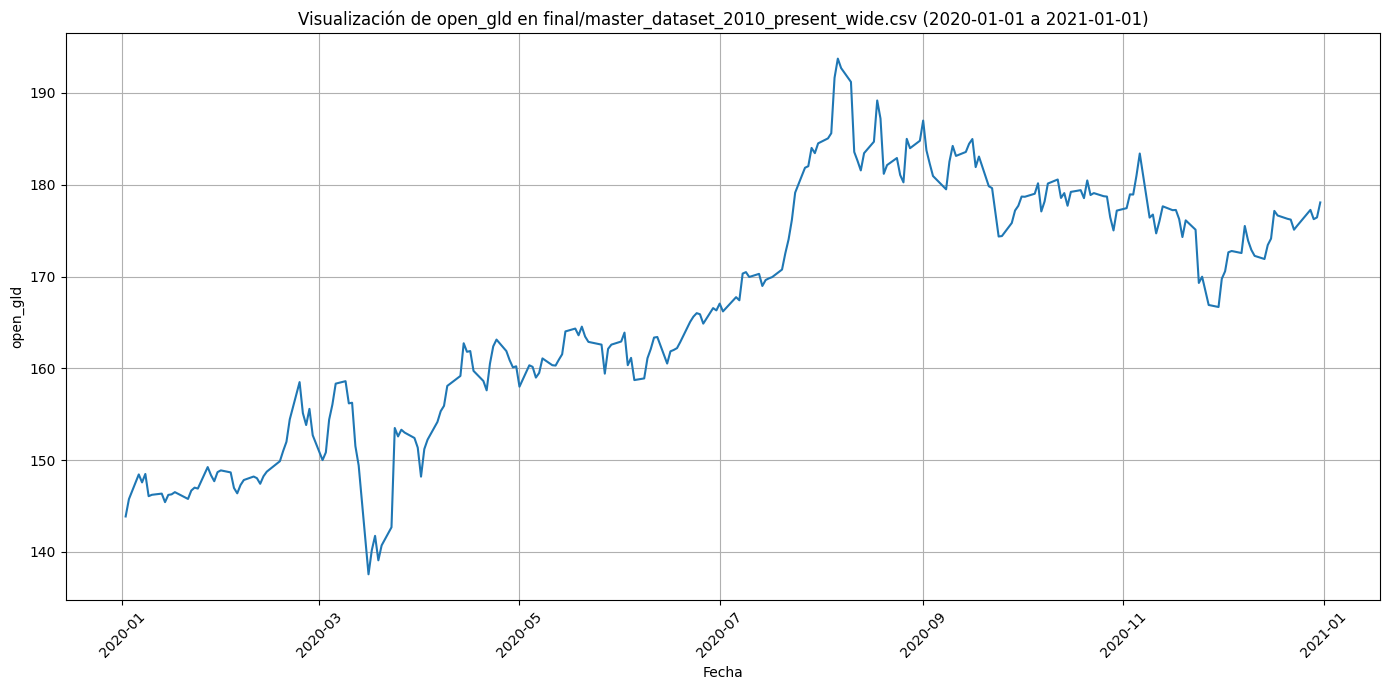

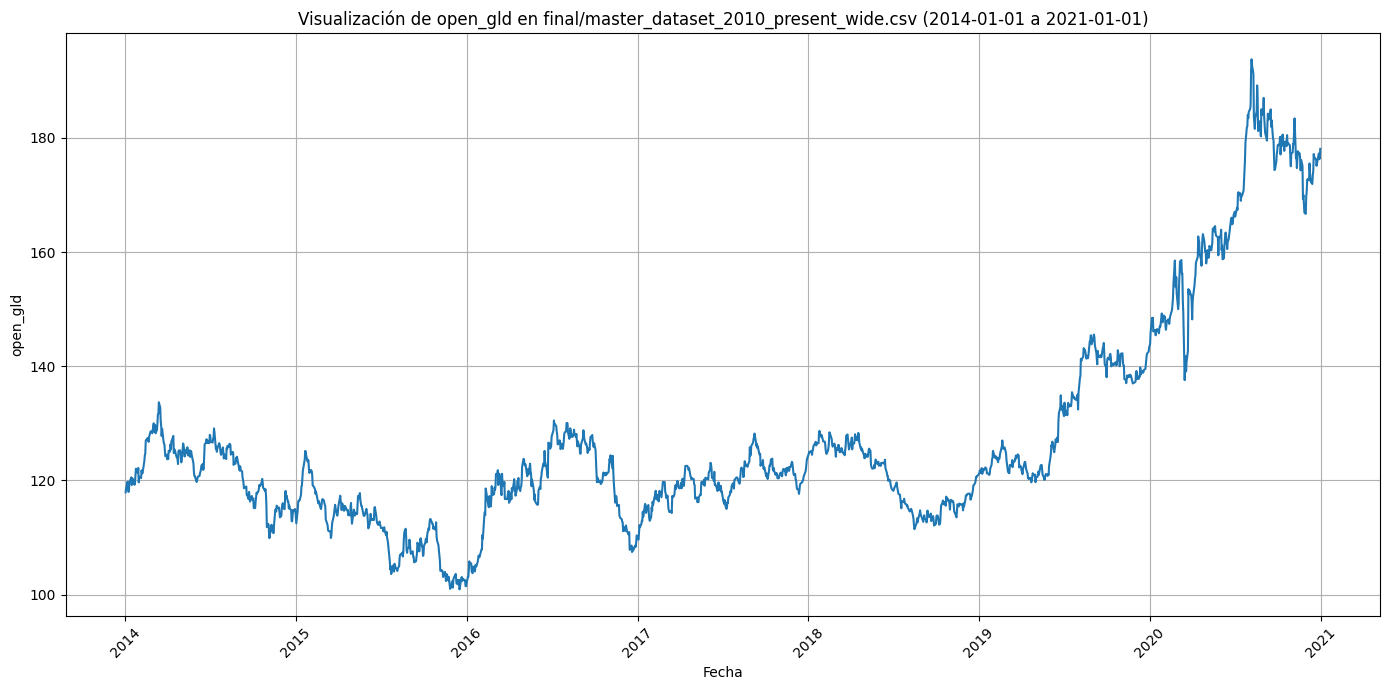

In [33]:
# ============================================================
# 16. Visualización de datos de archivos de salida
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, Text, DatePicker
from IPython.display import display

def visualize_file_data(file_name, column_name, start_date, end_date):
    file_path = PROJECT_ROOT / file_name

    if not file_path.exists():
        print(f"Error: El archivo '{file_name}' no se encontró en {PROJECT_ROOT}.")
        return

    try:
        df = pd.read_csv(file_path)
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date'])
        df = df[(df['date'] >= pd.to_datetime(start_date)) & (df['date'] <= pd.to_datetime(end_date))]

        if column_name not in df.columns:
            print(f"Error: La columna '{column_name}' no existe en el archivo '{file_name}'.")
            print(f"Columnas disponibles: {', '.join(df.columns.tolist())}")
            return

        if df.empty:
            print("No hay datos para el rango de fechas seleccionado.")
            return

        plt.figure(figsize=(14, 7))
        sns.lineplot(x='date', y=column_name, data=df, hue='asset' if 'asset' in df.columns else None)
        plt.title(f'Visualización de {column_name} en {file_name} ({start_date} a {end_date})')
        plt.xlabel('Fecha')
        plt.ylabel(column_name)
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error al procesar o visualizar el archivo: {e}")


print("Introduce los detalles para visualizar un archivo:")

# Widgets interactivos para la entrada del usuario
file_input = Text(description='Nombre del archivo (ej. master_dataset_2010_present_long.csv):')
column_input = Text(description='Nombre de la columna (ej. adj_close, vix_fred):')
start_date_input = DatePicker(description='Fecha de inicio:', value=pd.to_datetime('2020-01-01').date())
end_date_input = DatePicker(description='Fecha de fin:', value=pd.to_datetime('2021-01-01').date())

def on_button_clicked(_):
    visualize_file_data(file_input.value, column_input.value, start_date_input.value, end_date_input.value)

from ipywidgets import Button, VBox
button = Button(description="Visualizar")
button.on_click(on_button_clicked)

display(VBox([file_input, column_input, start_date_input, end_date_input, button]))

## Archivos generados

Al finalizar el notebook se crean principalmente:

```text
data/raw/prices_yfinance_raw_long.csv
data/raw/fred_macro_raw.csv

data/processed/prices_features_final_assets.csv
data/processed/prices_features_final_assets_trimmed.csv
data/processed/macro_normalized.csv
data/processed/macro_aligned_to_market_dates.csv

data/final/master_dataset_2010_present_long.csv
data/final/master_dataset_2010_present_wide.csv

reports/quality_summary.csv
reports/coverage_by_asset.csv
reports/missing_values_master_long.csv
reports/missing_values_master_wide.csv
```

## Recomendación

Para la fase de datos, usa como archivo principal:

```text
data/final/master_dataset_2010_present_long.csv
```

La versión ancha:

```text
data/final/master_dataset_2010_present_wide.csv
```

puede ser útil posteriormente para modelado, pero no reemplaza la tabla larga como base trazable.